In [2]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [4]:
from keras.datasets import cifar10

# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [5]:
# Normalize the data
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0


In [6]:
import keras
from keras import layers

# Model to mirror LeNet architecture

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(192, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,855,178 (136.78 MB)

 Trainable params: 35,855,178 (136.78 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(
    optimizer= opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [6]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:45000]
y_train = y_train[:45000]

In [10]:
y_val[2]

array([4], dtype=uint8)

In [11]:
y_train.shape

(45000, 1)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1411s 2s/step - accuracy: 0.2781 - loss: 1.9346 - val_accuracy: 0.4578 - val_loss: 1.5131
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1401s 2s/step - accuracy: 0.4858 - loss: 1.4061 - val_accuracy: 0.5550 - val_loss: 1.2507
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1384s 2s/step - accuracy: 0.6016 - loss: 1.1223 - val_accuracy: 0.6476 - val_loss: 0.9935
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1392s 2s/step - accuracy: 0.6741 - loss: 0.9270 - val_accuracy: 0.6982 - val_loss: 0.8785
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1388s 2s/step - accuracy: 0.7262 - loss: 0.7789 - val_accuracy: 0.7402 - val_loss: 0.7487
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1403s 2s/step - accuracy: 0.7693 - loss: 0.6574 - val_accuracy: 0.7478 - val_loss: 0.7323
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1386s 2s/step - accuracy: 0.8061 - loss: 0.5557 - val_accuracy: 0.7620 - val_loss: 0.6939
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1396s 2s/step - accuracy: 0.8416 - loss: 0.4565 - 

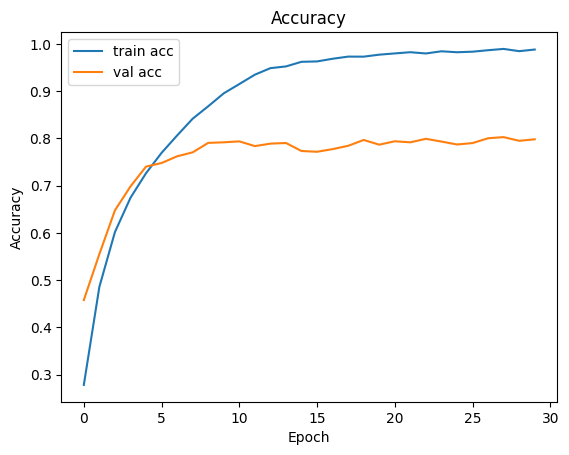

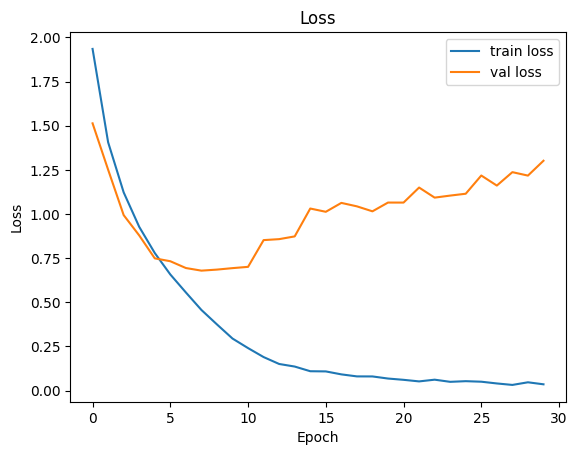

In [13]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
import keras
from keras import layers
opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

new_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(192, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
new_model.compile(
    optimizer= opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

new_history = new_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 1303s 2s/step - accuracy: 0.2838 - loss: 1.9130 - val_accuracy: 0.4372 - val_loss: 1.4842
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 1282s 2s/step - accuracy: 0.4950 - loss: 1.3855 - val_accuracy: 0.5754 - val_loss: 1.1870
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 1284s 2s/step - accuracy: 0.6023 - loss: 1.1145 - val_accuracy: 0.6436 - val_loss: 1.0353


In [11]:
#output model
new_model.save('CNN_cifar10_0_6023_Alexnet.keras')